In [ ]:
# ============================================
# Crime Prediction in Charlotte
# Using CMPD_Incidents-Shorter.csv
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# 1. Load the dataset
# -----------------------------
# NOTE: This file is the shortened CMPD incidents data provided.
file_path = "CMPD_Incidents(Shorter).csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (100000, 29)

Columns:
['X', 'Y', 'YEAR', 'INCIDENT_REPORT_ID', 'LOCATION', 'CITY', 'STATE', 'ZIP', 'X_COORD_PUBLIC', 'Y_COORD_PUBLIC', 'LATITUDE_PUBLIC', 'LONGITUDE_PUBLIC', 'DIVISION_ID', 'CMPD_PATROL_DIVISION', 'NPA', 'DATE_REPORTED', 'DATE_INCIDENT_BEGAN', 'DATE_INCIDENT_END', 'ADDRESS_DESCRIPTION', 'LOCATION_TYPE_DESCRIPTION', 'PLACE_TYPE_DESCRIPTION', 'PLACE_DETAIL_DESCRIPTION', 'CLEARANCE_STATUS', 'CLEARANCE_DETAIL_STATUS', 'CLEARANCE_DATE', 'HIGHEST_NIBRS_CODE', 'HIGHEST_NIBRS_DESCRIPTION', 'OBJECTID', 'GlobalID']

First 5 rows:
              X              Y  YEAR INCIDENT_REPORT_ID  \
0  1.433992e+06  578794.000085  2017   20171013-0911-00   
1  1.456134e+06  563839.000139  2017   20170115-1910-04   
2  1.469862e+06  522751.999964  2020   20200311-0808-04   
3  1.444937e+06  563099.999977  2020   20201221-1742-04   
4  1.449123e+06  544525.000053  2018   20180830-1155-02   

                 LOCATION       CITY STATE      ZIP  X_COORD_PUBLIC  \
0       6300 DAY LILLY L

In [89]:
# -----------------------------
# 2. Select relevant columns
# -----------------------------
# Target:
#   - HIGHEST_NIBRS_DESCRIPTION (description of the most serious offense)
#
# Feature candidates:
#   - DATE_INCIDENT_BEGAN: when the incident started
#   - CMPD_PATROL_DIVISION: patrol division (area within Charlotte)
#   - LATITUDE_PUBLIC / LONGITUDE_PUBLIC: location coordinates
#   - PLACE_TYPE_DESCRIPTION / LOCATION_TYPE_DESCRIPTION: type of place / indoors vs outdoors
#   - CLEARANCE_STATUS: clearance info
#   - YEAR: year of the incident

columns_to_use = [
    "HIGHEST_NIBRS_DESCRIPTION",
    "DATE_INCIDENT_BEGAN",
    "CMPD_PATROL_DIVISION",
    "LATITUDE_PUBLIC",
    "LONGITUDE_PUBLIC",
    "PLACE_TYPE_DESCRIPTION",
    "LOCATION_TYPE_DESCRIPTION",
    "CLEARANCE_STATUS",
    "YEAR"
]

df_model = df[columns_to_use].copy()

# -----------------------------
# 3. Clean data
# -----------------------------
# Drop rows without a crime description (target label).
df_model = df_model.dropna(subset=["HIGHEST_NIBRS_DESCRIPTION"])

# Convert the incident date to datetime.
df_model["DATE_INCIDENT_BEGAN"] = pd.to_datetime(
    df_model["DATE_INCIDENT_BEGAN"],
    errors="coerce"
)

# Drop rows where date parsing failed.
df_model = df_model.dropna(subset=["DATE_INCIDENT_BEGAN"])

# Group rare crime types into "Other" to simplify the classification task.
crime_counts = df_model["HIGHEST_NIBRS_DESCRIPTION"].value_counts()
min_count = 200  # threshold can be adjusted
rare_crimes = crime_counts[crime_counts < min_count].index

df_model["crime_type"] = df_model["HIGHEST_NIBRS_DESCRIPTION"].replace(rare_crimes, "Other")

In [90]:
# =============================
# 2. Select relevant columns
# =============================
# Select only the columns needed for modeling and discard others
#
# TARGET VARIABLE:
#   - HIGHEST_NIBRS_DESCRIPTION: The crime type we want to predict
#
# FEATURE VARIABLES:
#   - DATE_INCIDENT_BEGAN: Date when the incident occurred (for extracting time features)
#   - CMPD_PATROL_DIVISION: Police division/area where crime occurred
#   - LATITUDE_PUBLIC, LONGITUDE_PUBLIC: Geographic coordinates of the incident
#   - PLACE_TYPE_DESCRIPTION: Type of place (e.g., parking lot, street, building)
#   - LOCATION_TYPE_DESCRIPTION: Detailed location classification
#   - CLEARANCE_STATUS: Whether the crime was cleared/solved
#   - YEAR: Year the incident occurred

columns_to_use = [
    "HIGHEST_NIBRS_DESCRIPTION",  # Target: crime type
    "DATE_INCIDENT_BEGAN",  # Feature: incident date
    "CMPD_PATROL_DIVISION",  # Feature: patrol division
    "LATITUDE_PUBLIC",  # Feature: location latitude
    "LONGITUDE_PUBLIC",  # Feature: location longitude
    "PLACE_TYPE_DESCRIPTION",  # Feature: place type
    "LOCATION_TYPE_DESCRIPTION",  # Feature: location type
    "CLEARANCE_STATUS",  # Feature: case status

    "YEAR"  # Feature: year of incidentdf_model = df[columns_to_use].copy()

]# Create a copy of the selected columns to avoid modifying the original dataset


In [91]:
# -----------------------------
# 4. Feature engineering
# -----------------------------
# Extract month, day of week, and weekend indicator from the incident date.
df_model["month"] = df_model["DATE_INCIDENT_BEGAN"].dt.month
df_model["day_of_week"] = df_model["DATE_INCIDENT_BEGAN"].dt.day_name()
df_model["weekend"] = df_model["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Note: no hour column is visible in this CSV sample, so we cannot create time-of-day here.

# Define target and feature columns.
target_col = "crime_type"

feature_cols = [
    "CMPD_PATROL_DIVISION",
    "LATITUDE_PUBLIC",
    "LONGITUDE_PUBLIC",
    "PLACE_TYPE_DESCRIPTION",
    "LOCATION_TYPE_DESCRIPTION",
    "CLEARANCE_STATUS",
    "YEAR",
    "month",
    "day_of_week",
    "weekend"
]

X = df_model[feature_cols]
y = df_model[target_col]

print("\nTarget class counts (after grouping rare types):")
print(y.value_counts().head(20))


Target class counts (after grouping rare types):
crime_type
Theft From Motor Vehicle                     9988
All Other Offenses                           9681
Other Unlisted Non-Criminal                  9514
Simple Assault                               8679
All Other Thefts                             8479
Shoplifting                                  6127
Damage/Vandalism Of Property                 5697
Motor Vehicle Theft                          4998
Burglary/B&E                                 4669
Drug/Narcotic Violations                     3833
Intimidation                                 3255
Aggravated Assault                           3097
Missing Person                               2734
False Pretenses/Swindle                      1831
Other                                        1699
Robbery                                      1665
Theft of Motor Vehicle Parts from Vehicle    1642
Theft From Building                          1099
Identity Theft                         

In [92]:
# -----------------------------
# 5. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# 6. Preprocessing pipelines
# -----------------------------
numeric_features = [
    "LATITUDE_PUBLIC",
    "LONGITUDE_PUBLIC",
    "YEAR",
    "month",
    "weekend"
]

categorical_features = [
    "CMPD_PATROL_DIVISION",
    "PLACE_TYPE_DESCRIPTION",
    "LOCATION_TYPE_DESCRIPTION",
    "CLEARANCE_STATUS",
    "day_of_week"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [93]:
# -----------------------------
# 7. Define models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=15,
        min_samples_leaf=20
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

# Wrap each model in a pipeline with preprocessing.
pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

In [94]:
# -----------------------------
# 8. Train and evaluate models
# -----------------------------
results = []

for name, pipe in pipelines.items():
    print("\n" + "=" * 60)
    print(f"Training: {name}")
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": acc
    })
    
    print(f"{name} Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)


Training: Logistic Regression


c:\Users\InTai\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.3207

Classification Report:
                                           precision    recall  f1-score   support

                                   Affray       0.00      0.00      0.00        42
                       Aggravated Assault       0.33      0.00      0.00       619
                       All Other Offenses       0.33      0.29      0.31      1936
                         All Other Thefts       0.20      0.24      0.22      1696
                             Burglary/B&E       0.20      0.38      0.26       934
                   Counterfeiting/Forgery       0.20      0.01      0.02       126
                 Credit Card/Teller Fraud       0.00      0.00      0.00       214
             Damage/Vandalism Of Property       0.17      0.01      0.02      1139
              Driving Under The Influence       0.26      0.22      0.24       105
                Drug Equipment Violations       0.00      0.00      0.00       106
                 Drug/Nar

C:\Users\InTai\AppData\Local\Temp\ipykernel_21892\99827210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="Set2")


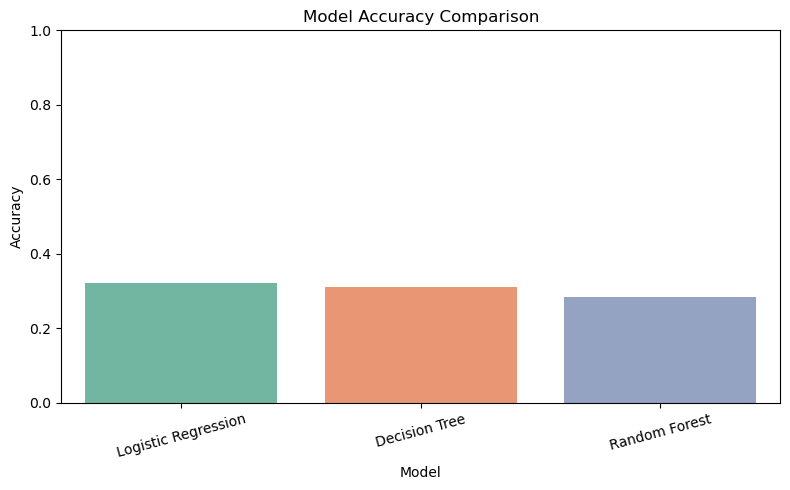

In [95]:
# -----------------------------
# 9. Plot model comparison bar chart
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="Set2")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

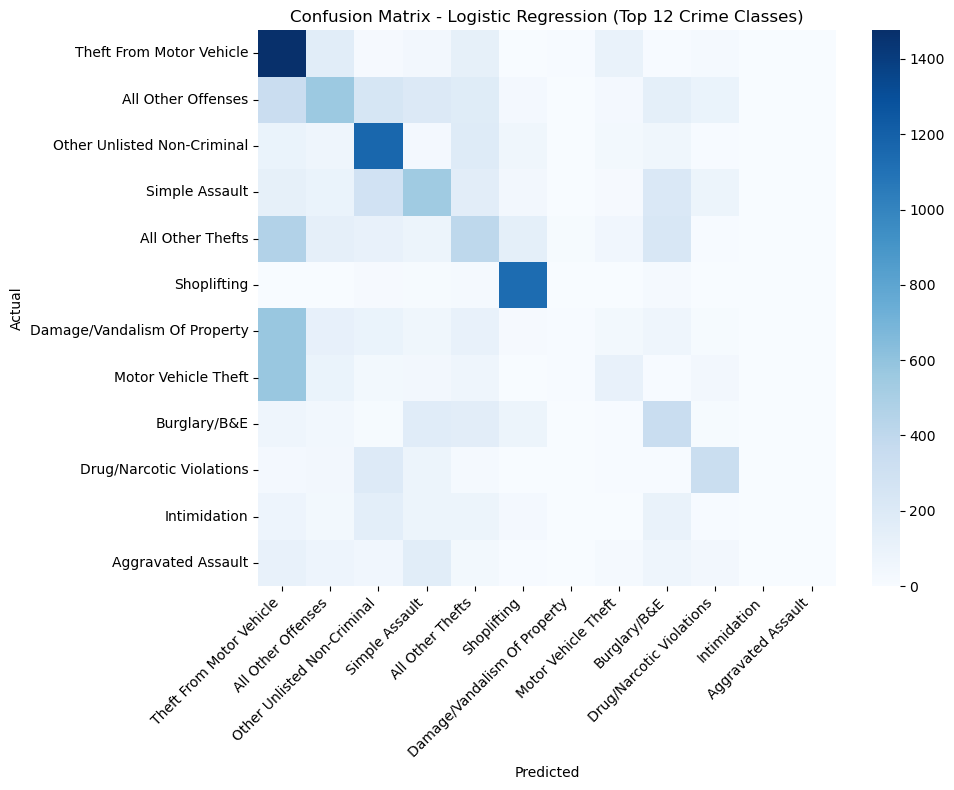

In [96]:
# -----------------------------
# 10. Confusion matrix for best model
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]

y_pred_best = best_pipe.predict(X_test)

# Use top 12 most common crime classes for readability.
top_labels = y_test.value_counts().head(12).index.tolist()
cm = confusion_matrix(y_test, y_pred_best, labels=top_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels
)
plt.title(f"Confusion Matrix - {best_model_name} (Top 12 Crime Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Top 20 Important Features:
                                   feature  importance
1                         LONGITUDE_PUBLIC    0.192898
0                          LATITUDE_PUBLIC    0.192730
3                                    month    0.154328
2                                     YEAR    0.128505
26       LOCATION_TYPE_DESCRIPTION_Indoors    0.020110
25           PLACE_TYPE_DESCRIPTION_Retail    0.020072
33  CLEARANCE_STATUS_Exceptionally Cleared    0.018006
36                      day_of_week_Friday    0.015504
42                   day_of_week_Wednesday    0.015433
37                      day_of_week_Monday    0.015334
41                     day_of_week_Tuesday    0.015219
34                   CLEARANCE_STATUS_Open    0.015121
40                    day_of_week_Thursday    0.015043
24      PLACE_TYPE_DESCRIPTION_Residential    0.012745
30   LOCATION_TYPE_DESCRIPTION_Parking Lot    0.012060
31      CLEARANCE_STATUS_Cleared by Arrest    0.010696
4                                  we

C:\Users\InTai\AppData\Local\Temp\ipykernel_21892\1430178524.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


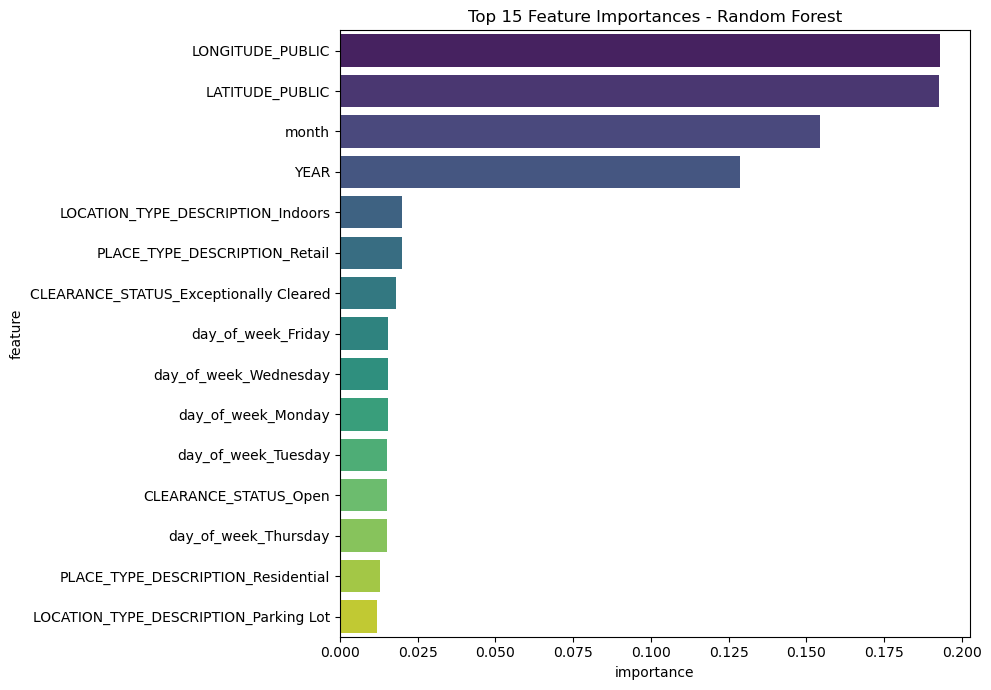

In [97]:
# -----------------------------
# 11. Feature importance for Random Forest
# -----------------------------
rf_pipe = pipelines["Random Forest"]
rf_pipe.fit(X_train, y_train)

# Recover one-hot encoded feature names.
ohe = rf_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_names)

rf_model = rf_pipe.named_steps["model"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Important Features:")
print(feat_imp.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feat_imp.head(15),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

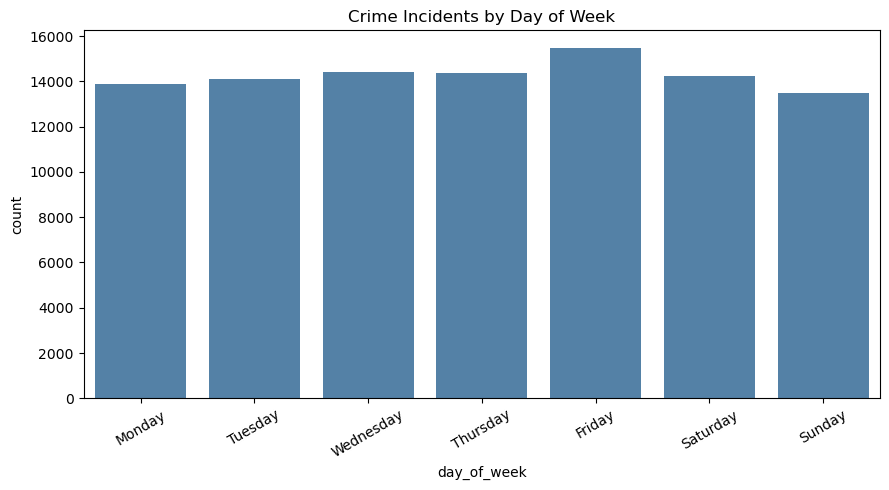

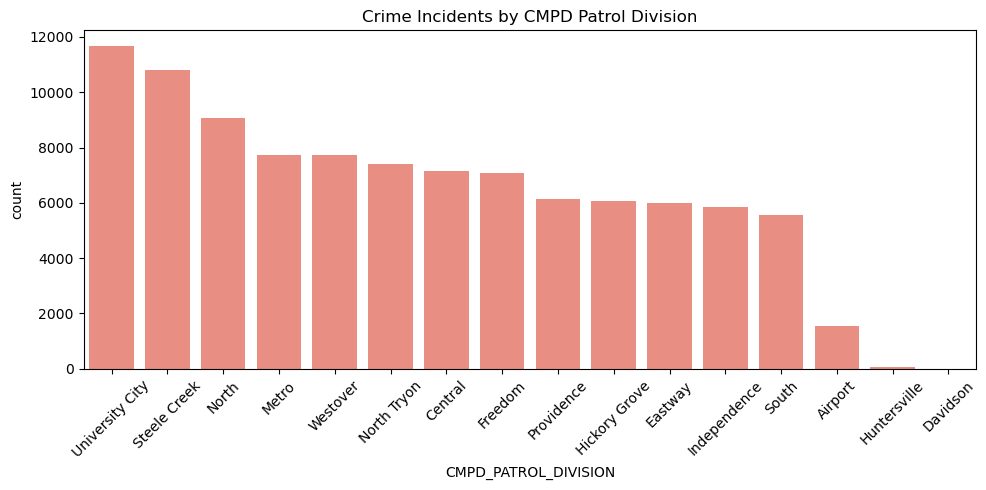

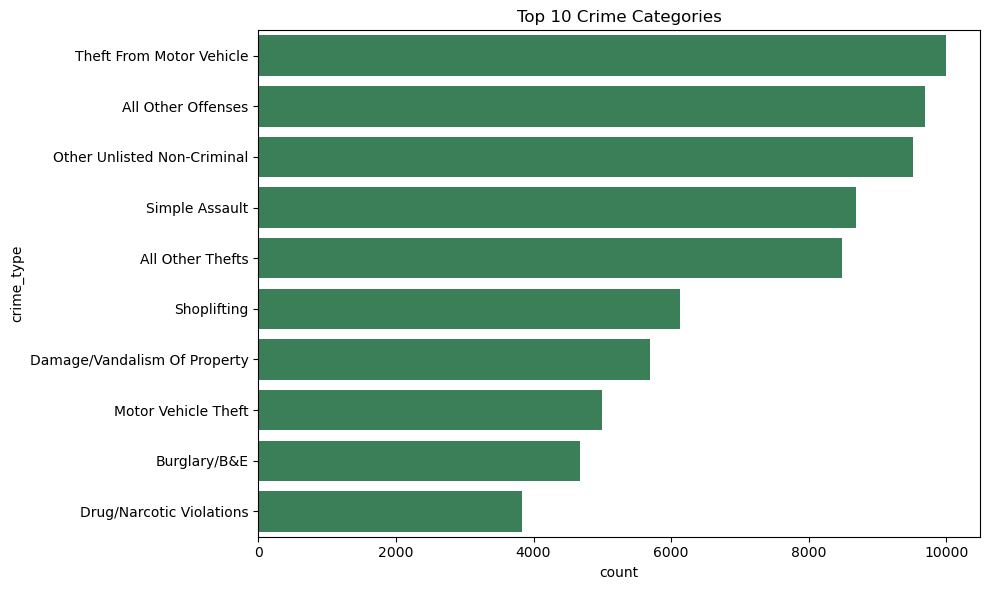

In [98]:
# -----------------------------
# 12. Descriptive pattern plots
# -----------------------------
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Crimes by day of week
plt.figure(figsize=(9, 5))
sns.countplot(data=df_model, x="day_of_week", order=day_order, color="steelblue")
plt.title("Crime Incidents by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Crimes by patrol division
plt.figure(figsize=(10, 5))
division_order = df_model["CMPD_PATROL_DIVISION"].value_counts().index
sns.countplot(data=df_model, x="CMPD_PATROL_DIVISION", order=division_order, color="salmon")
plt.title("Crime Incidents by CMPD Patrol Division")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 10 crime categories (after grouping rare ones)
top_crime_order = df_model["crime_type"].value_counts().head(10).index

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_model[df_model["crime_type"].isin(top_crime_order)],
    y="crime_type",
    order=top_crime_order,
    color="seagreen"
)
plt.title("Top 10 Crime Categories")
plt.tight_layout()
plt.show()

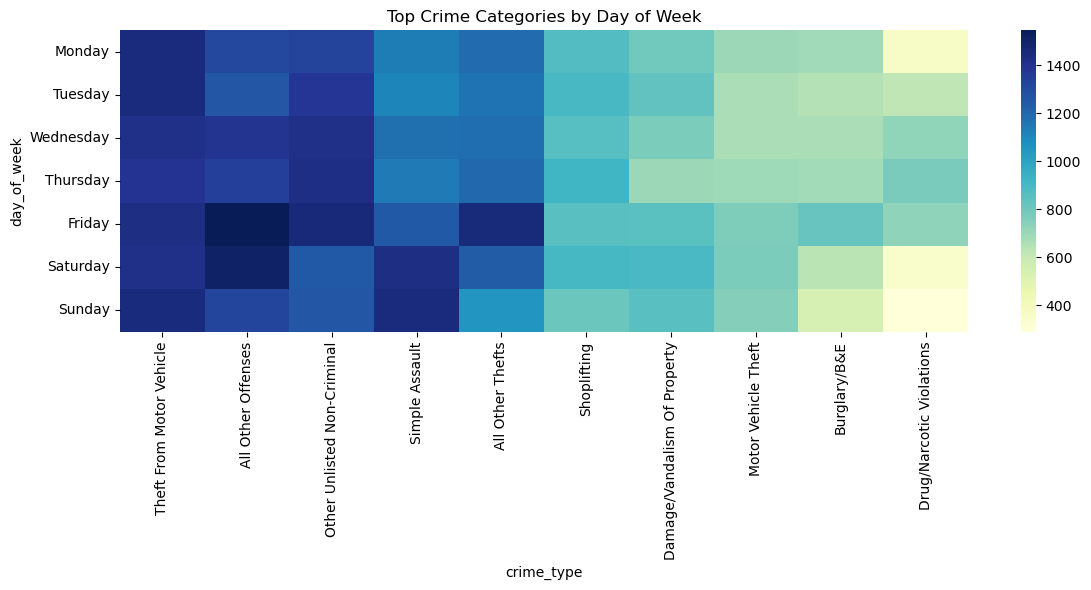

In [99]:
# -----------------------------
# 13. Heatmap: top crime categories by day of week
# -----------------------------
crime_day_table = pd.crosstab(df_model["day_of_week"], df_model["crime_type"])
crime_day_table = crime_day_table.reindex(day_order)

top10_crimes = df_model["crime_type"].value_counts().head(10).index
crime_day_top = crime_day_table[top10_crimes]

plt.figure(figsize=(12, 6))
sns.heatmap(crime_day_top, cmap="YlGnBu")
plt.title("Top Crime Categories by Day of Week")
plt.tight_layout()
plt.show()